# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [ ]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.3 huggingface_hub==0.30.1 -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the dataset
superkart_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/model_deployment/project/SuperKart.csv")

In [ ]:
# Create a copy of the dataframe
df = superkart_data.copy()

# **Data Overview**

In [ ]:
# Display the first five rows of the dataset
df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [ ]:
# Display the number of rows and columns in the dataset
df.shape

(8763, 12)

- There are 8763 rows and 12 columns in the dataset.

In [ ]:
# List the columns and their data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


- There are 4 numerical and 7 categorical features, plus 1 numerical target variable (Product_Store_Sales_Total).

In [ ]:
# Find duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

- There are no duplicate rows.

In [ ]:
# Find missing values in the dataset
df.isnull().sum()

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


- There are no missing values.

In [ ]:
# Number of unique Products
df["Product_Id"].nunique()

8763

- Each row in the dataset has a unique product.

In [ ]:
# Drop the Product_Id column as it is not a useful feature for prediction
df.drop("Product_Id", axis=1, inplace=True)

In [ ]:
# Identify the numerical and categorical columns in the dataset
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

In [ ]:
numerical_cols

['Product_Weight',
 'Product_Allocated_Area',
 'Product_MRP',
 'Store_Establishment_Year',
 'Product_Store_Sales_Total']

In [ ]:
categorical_cols

['Product_Sugar_Content',
 'Product_Type',
 'Store_Id',
 'Store_Size',
 'Store_Location_City_Type',
 'Store_Type']

In [ ]:
# Statistical overview of the numerical features
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000


## Statistical Overview - Numerical Features

**Product_Weight**
- Symmetric distribution with mean(12.65) ≈ median(12.66).
- Products cluster tightly around the mean (12.65 kg), suggesting standardized product sizing in the catalog.
- No extreme outliers; range 4-22 kg is reasonable for retail products.

**Product_Allocated_Area**
- Right-skewed distribution (mean 0.069 > median 0.056).
- Significant disparity in shelf space allocation across products; some premium products receive more display area than others (0.004-0.298 range).

**Product_MRP**
- Symmetric and fairly concentrated distribution with mean(147.03) ≈ median(146.74).
- Good price diversity across product catalog (31-266); moderate spread suitable for model training.

**Store_Establishment_Year**
- Highly concentrated with strong clustering at 2009 (75th percentile = max = 2009)
- Most stores established between 1998-2009; only a few older outliers (1987).

**Product_Store_Sales_Total**
- Mean revenue per Product is ~3,464, with median nearly identical at ~3,452 - indicating a central distribution without strong median-mean divergence.
- Minimum value is very low (33), while the maximum is 8,000, indicating a few extreme high-sales outliers.

In [ ]:
# Statistical overview of the categorical features
df[categorical_cols].describe().T

,count,unique,top,freq
Product_Sugar_Content,8763,4,Low Sugar,4885
Product_Type,8763,16,Fruits and Vegetables,1249
Store_Id,8763,4,OUT004,4676
Store_Size,8763,3,Medium,6025
Store_Location_City_Type,8763,3,Tier 2,6262
Store_Type,8763,4,Supermarket Type2,4676


In [ ]:
# check the proportion of occurrences of each unique value in each categorical column
for col in categorical_cols:
    print(df[col].value_counts(normalize=True))
    print("-" * 50)

Product_Sugar_Content
Low Sugar    0.557457
Regular      0.256875
No Sugar     0.173342
reg          0.012325
Name: proportion, dtype: float64
--------------------------------------------------
Product_Type
Fruits and Vegetables    0.142531
Snack Foods              0.131119
Frozen Foods             0.092548
Dairy                    0.090836
Household                0.084446
Baking Goods             0.081707
Canned                   0.077257
Health and Hygiene       0.071665
Meat                     0.070524
Soft Drinks              0.059226
Breads                   0.022823
Hard Drinks              0.021226
Others                   0.017232
Starchy Foods            0.016090
Breakfast                0.012096
Seafood                  0.008673
Name: proportion, dtype: float64
--------------------------------------------------
Store_Id
OUT004    0.533607
OUT001    0.180988
OUT003    0.153943
OUT002    0.131462
Name: proportion, dtype: float64
-----------------------------------------------

## Statistical Overview - Categorical Features

**Product_Sugar_Content**
- Total 4 categories; 'Low Sugar' products dominate (55.7% of products, freq=4885) Regular and No Sugar products.
- There is a category 'reg' which might be just the short form of Regular.

**Product_Type**
- Total 16 diverse categories; 'Fruits and Vegetables' most common (14.3%, freq=1249) closely followed by 'Snack Foods' (13.1%).

**Store_Id**
- Only 4 unique stores; 'OUT004' accounts for majority (53.4%, freq=4676).
- Imbalanced store representation; potential bias in sales data towards this store.

**Store_Size**
- Catigorized into 3 sizes; 'Medium' size dominates (68.8%, freq=6025).
- Most stores are medium-sized; 'High' and 'Small' are underrepresented.

**Store_Location_City_Type**
- Categorized into 3 tiers; 'Tier 2' cities most prevalent (71.5%, freq=6262).

**Store_Type**
- Categorized into 4 types; 'Supermarket Type2' most frequent (53.4%, freq=4676).
- Store_Id and Store_Type have exact same number of categories and proportions. We can infer each Store_Id and Store_Type combination is unique.

In [ ]:
# check the unique combinations of Store_Id and Store_Type
df[["Store_Id", "Store_Type"]].drop_duplicates()

,Store_Id,Store_Type
0,OUT004,Supermarket Type2
1,OUT003,Departmental Store
2,OUT001,Supermarket Type1
4,OUT002,Food Mart


- There is one-to-one mapping between Store_Id and Store_Type which indicates a perfect correlation. We can drop Store_Id.

In [ ]:
# Drop the Store_Id column
df.drop("Store_Id", axis=1, inplace=True)
df.shape

(8763, 10)

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

### Plotting functions

In [ ]:
# function to plot a boxplot and a histogram along the same scale.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=True, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    # creating the 2 subplots
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )
    # boxplot with a triangle to indicate the mean value of the column
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )
    # histogram with kde option
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )
    # add mean to the histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )
    # add median to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )

    plt.show() # show the plot

In [ ]:
# function to create labeled barplots

def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

### Target Variable

#### Product_Store_Sales_Total

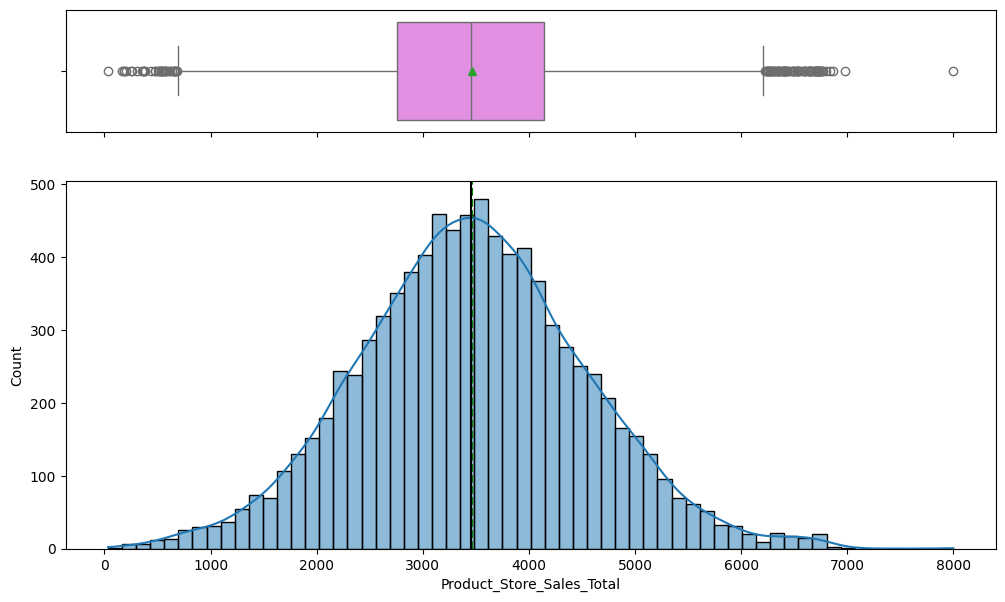

In [ ]:
histogram_boxplot(df, "Product_Store_Sales_Total")

- The distribution is slightly right-skewed, with the mean slightly higher than the median, indicating the presence of some higher revenue values.

- A wide range of revenue values is observed, with the majority falling between approximately 2000 and 5000.

- The boxplot shows some outliers on the higher end, suggesting a few products/stores generate significantly more revenue.

### Numerical Features

#### Product_Weight

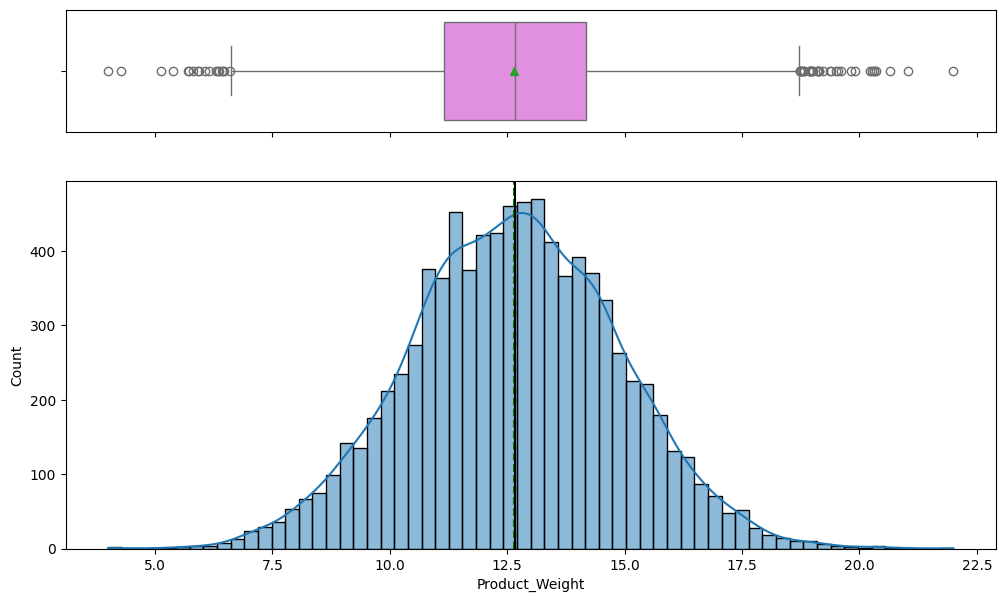

In [ ]:
histogram_boxplot(df, "Product_Weight")

- The distribution is roughly symmetric, with the mean and median being very close.

- Product weights are fairly concentrated, mostly ranging from 10 kg to 15 kg, indicating a standardized weight range for products.

- There are no significant outliers, and the distribution is well-behaved.

#### Product_Allocated_Area

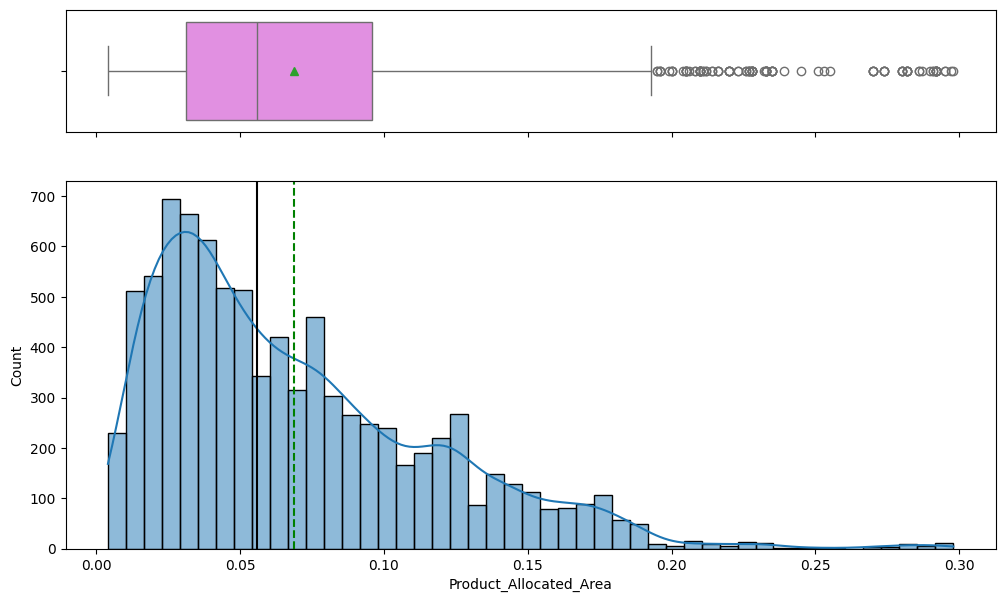

In [ ]:
histogram_boxplot(df, "Product_Allocated_Area")

- The distribution is strongly right-skewed, with the mean being considerably higher than the median.

- Most products are allocated a small area (below 0.1), but there are a few products with much larger allocated areas, suggesting premium or promotional placement.

- The presence of several outliers on the higher end of the allocated area indicates disproportionate display space for some products.

#### Product_MRP

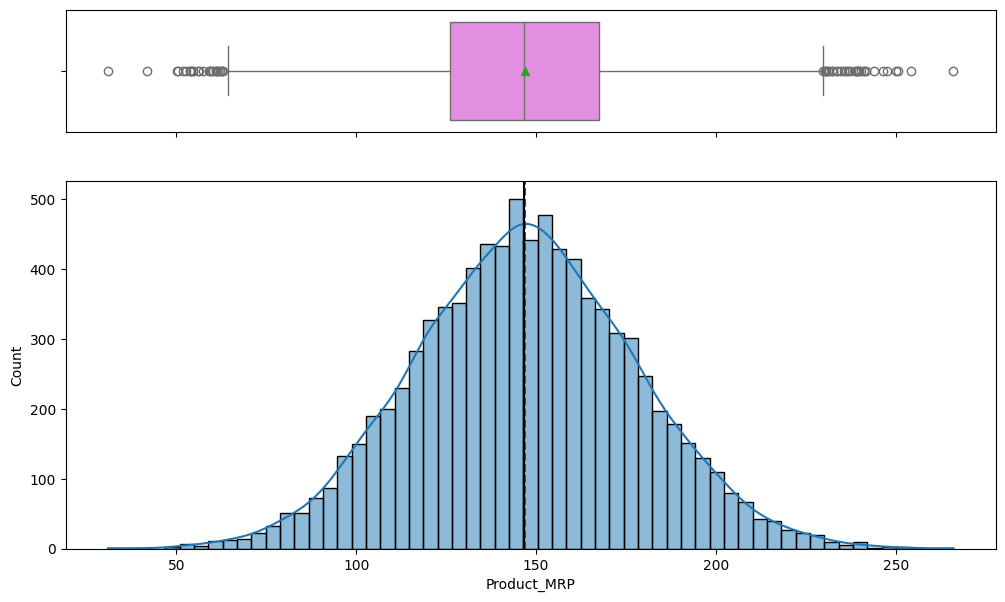

In [ ]:
histogram_boxplot(df, "Product_MRP")

- The distribution is generally uniform across the price range, with a slight bimodal tendency around the 100-120 and 150-180 mark.

- There are no apparent extreme outliers in the product Maximum Retail Price.

#### Store_Establishment_Year

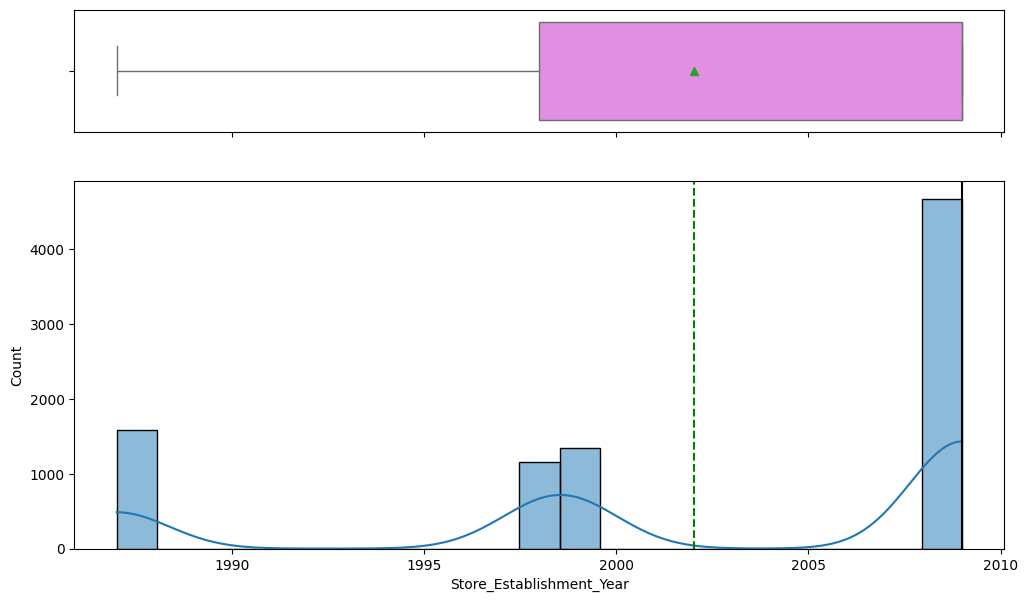

In [ ]:
histogram_boxplot(df, "Store_Establishment_Year")

- The distribution is left-skewed, with a notable concentration of stores established in later years (around 2009).

- The earliest established store is from 1987, and the latest is 2009, indicating a relatively recent establishment history for most stores in the dataset.

- The majority of stores were established between 1998 and 2009, with a strong peak towards 2009.

### Categorical Features

#### Product_Sugar_Content

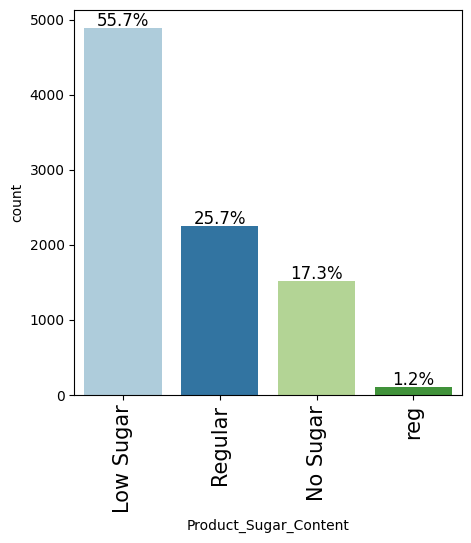

In [ ]:
labeled_barplot(df, 'Product_Sugar_Content', perc=True)

- **Low Sugar** products dominate the inventory, making up over 55% of all products.

- **Regular** and **No Sugar** products constitute the next largest categories, with **reg** likely being a variant of **Regular**.

#### Product_Type

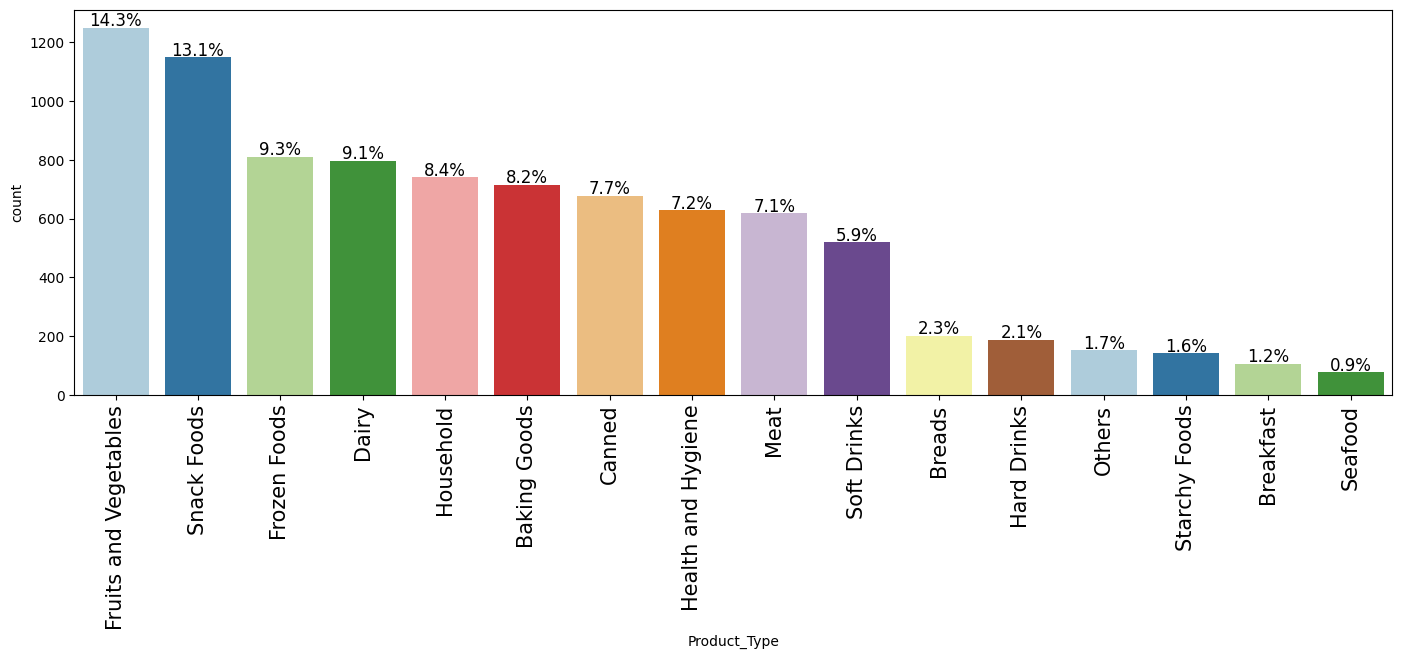

In [ ]:
labeled_barplot(df, 'Product_Type', perc=True, n=16)

- **Fruits and Vegetables** and **Snack Foods** are the most common product types, collectively accounting for more than 27% of the products.

- The top five product types (**'Fruits and Vegetables', 'Snack Foods', 'Frozen Foods', 'Dairy', 'Household'**) represent a substantial portion of the product catalog.

- Less common product types like **Seafood** and **Breakfast** each make up just about 2% of the total products.

#### Store_Size

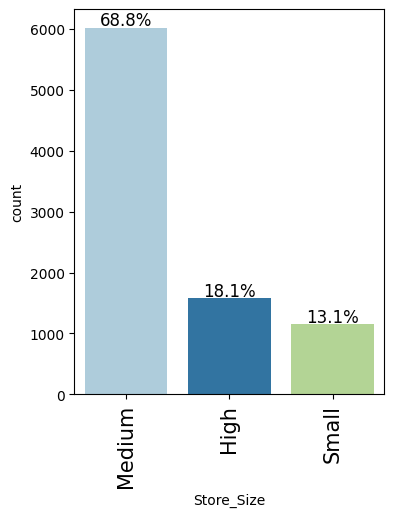

In [ ]:
labeled_barplot(df, 'Store_Size', perc=True)

- **Medium** sized stores are by far the most prevalent, representing nearly 69% of all stores.

- **High** and **Small** sized stores are less common, making up approximately 18% and 13% respectively.

- This distribution suggests that the majority of sales data is likely concentrated within medium-sized stores.

#### Store_Location_City_Type

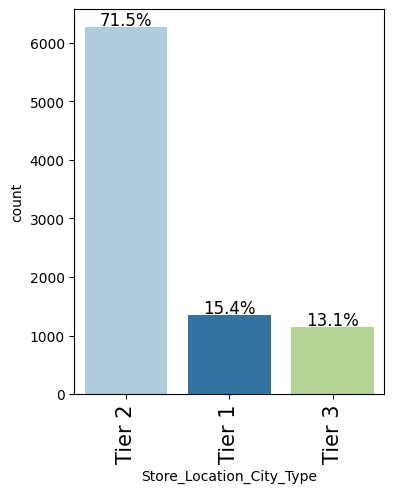

In [ ]:
labeled_barplot(df, 'Store_Location_City_Type', perc=True)

- Around 71.5% of the products are sold at the stores located in **Tier 2** cities, making them the dominant location type.

- Stores in **Tier 1** and **Tier 3** cities host significantly fewer products, each accounting for around 13-15%.

#### Store_Type

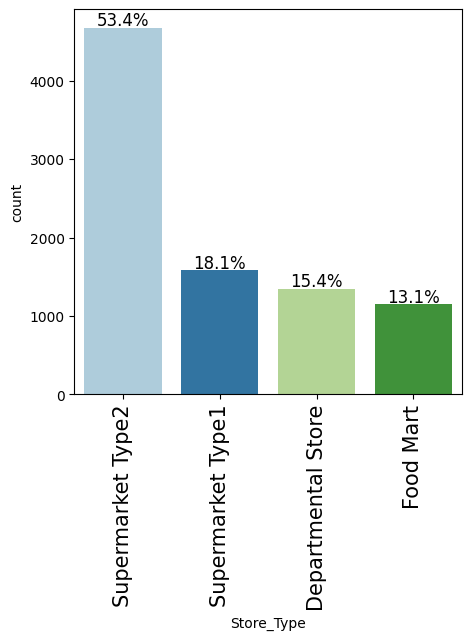

In [ ]:
labeled_barplot(df, 'Store_Type', perc=True)

- **Supermarket Type2** is the most frequent store type, comprising over 53% of all stores.

- **Supermarket Type1**, **Departmental Store**, and **Food Mart** are less common.

- This pattern strongly correlates with the distribution observed in Store_Id, indicating a one-to-one mapping as noted earlier.

## Bivariate Analysis

In [ ]:
# function to create a correlation heatmap
def correlation_heatmap(data, features):
    """
    Correlation heatmap

    data: dataframe
    features: list of features to be included in the heatmap
    """
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        data[features].corr(),
        annot=True,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        linewidths=0.5,
    )
    plt.show()

# function to plot numerical features against the target variable using scatter plots
def scatter_plots(data, features, target):
    """
    Scatter plots of numerical features against the target variable

    data: dataframe
    features: list of numerical features to be plotted
    target: target variable
    """
    for feature in features:
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=data, x=feature, y=target)
        plt.title(f"{feature} vs {target}")
        plt.show()

# function to plot categorical features with the target variable using a boxplot
def boxplot_cat_target(data, feature, target):
    """
    Boxplot of categorical feature with the target variable

    data: dataframe
    feature: categorical feature column
    target: target variable column
    """
    plt.figure(figsize=(12, 7))
    sns.boxplot(data=data, x=feature, y=target, palette="Set2")
    plt.xticks(rotation=90)
    plt.show()

### Numerical Features vs. Target Variable

#### Correlation Heatmap of Numerical Features

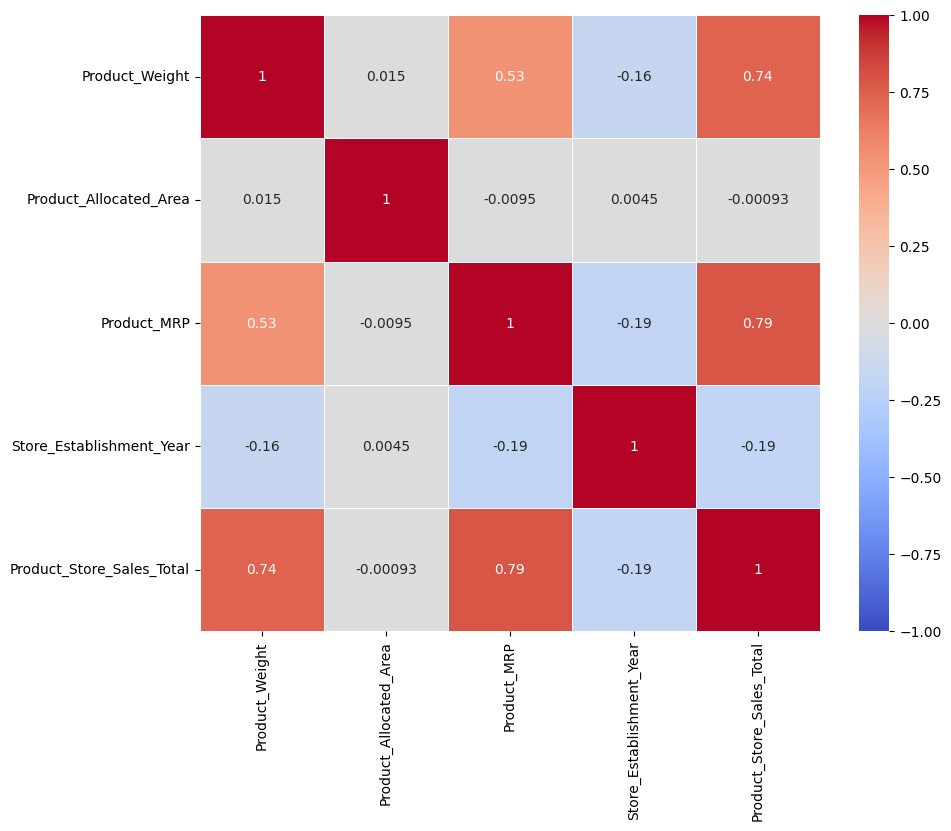

In [ ]:
# Generate correlation heatmap for numerical features
correlation_heatmap(df, numerical_cols)

#### Scatter Plots

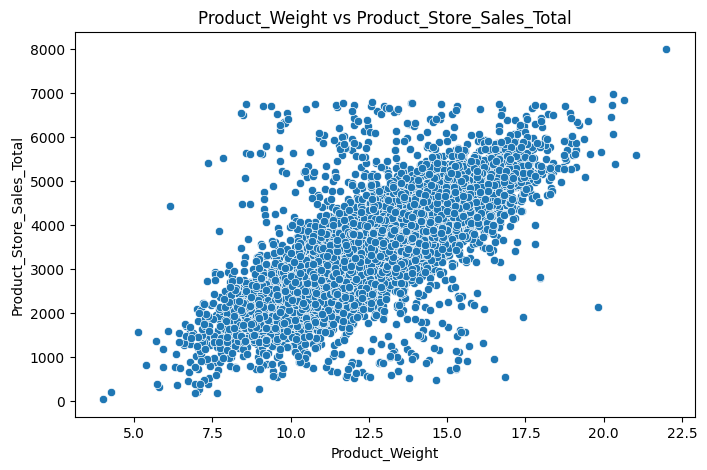

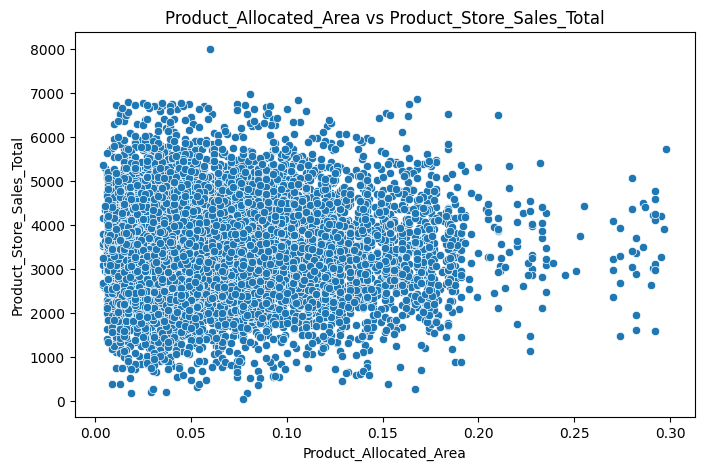

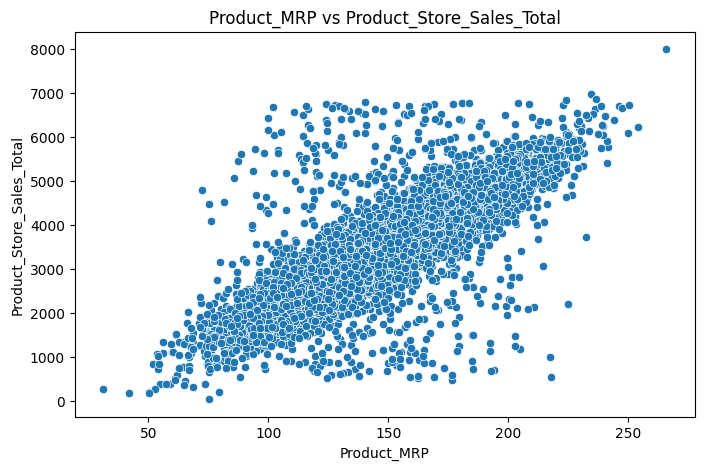

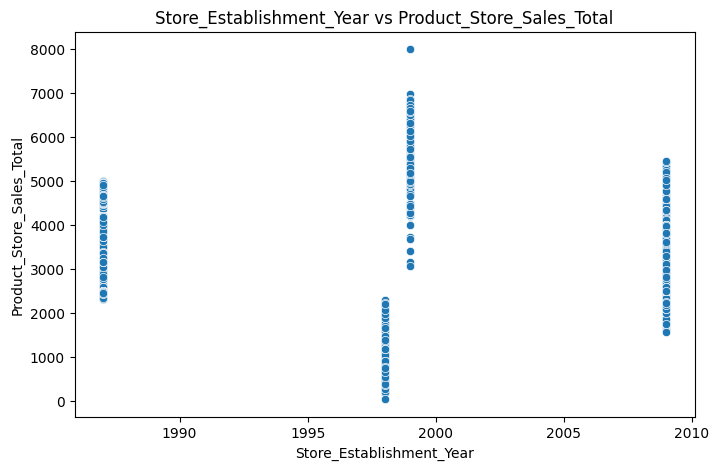

In [ ]:
scatter_plots(df, [col for col in numerical_cols if col != 'Product_Store_Sales_Total'], 'Product_Store_Sales_Total')

#### **Observations**

**Correlations with Target Variable (Product_Store_Sales_Total):**

- **Product_MRP** shows a strong positive correlation (0.79). This suggests that higher priced products tend to generate higher revenue.

- **Product_Weight** also exhibits a strong positive correlation (0.74). This implies that heavier products contribute more to total revenue.

- **Store_Establishment_Year** has a weak negative correlation (-0.19). This indicates that older stores (lower establishment year) might have slightly higher sales, or vice-versa, but the effect is not strong.

- **Product_Allocated_Area** has a very negligible correlation (-0.001), suggesting it's not a strong linear predictor of sales in this dataset.

**Multicollinearity among Independent Numerical Features:**

- A moderate positive correlation (0.53) exists between **Product_Weight** and **Product_MRP**. This indicates some degree of multicollinearity between these two features.

- All other numerical independent features (**Product_Allocated_Area, Store_Establishment_Year**) show very low correlations with each other, indicating no significant multicollinearity issues among them.

### Categorical Features vs. Target Variable

#### Product_Sugar_Content vs Product_Store_Sales_Total

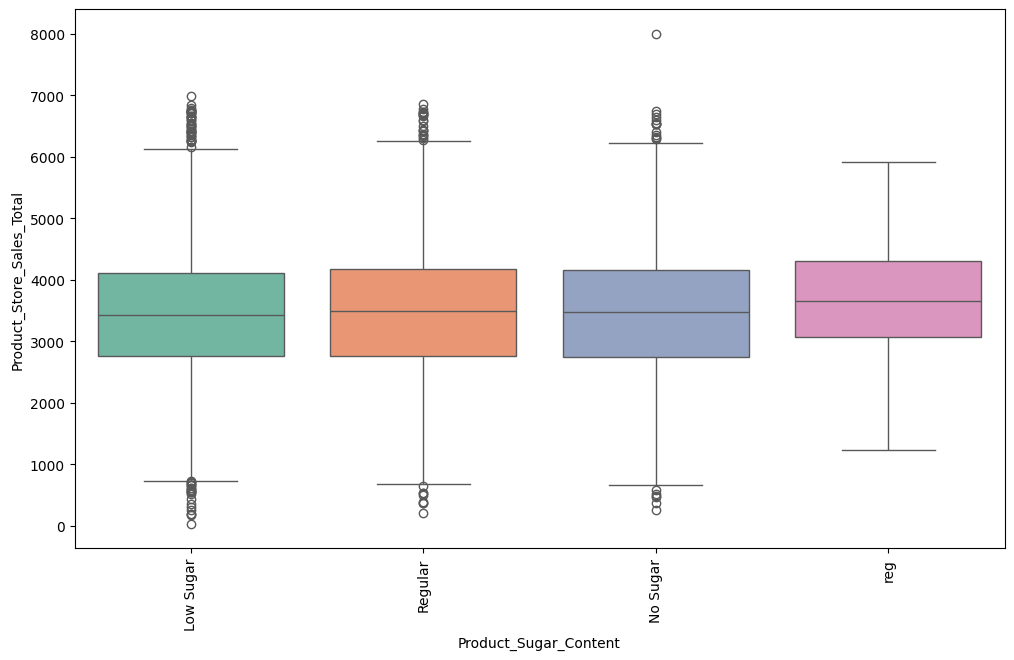

In [ ]:
boxplot_cat_target(df, 'Product_Sugar_Content', 'Product_Store_Sales_Total')

- Products with **Regular** sugar content show slightly higher median sales compared to **Low Sugar** and **No Sugar** products.

- The **reg** category (likely a variant of 'Regular') has a similar sales distribution to **Regular**.

- All categories exhibit a similar spread of sales, with several outliers, especially on the higher end.

#### Product_Type vs Product_Store_Sales_Total

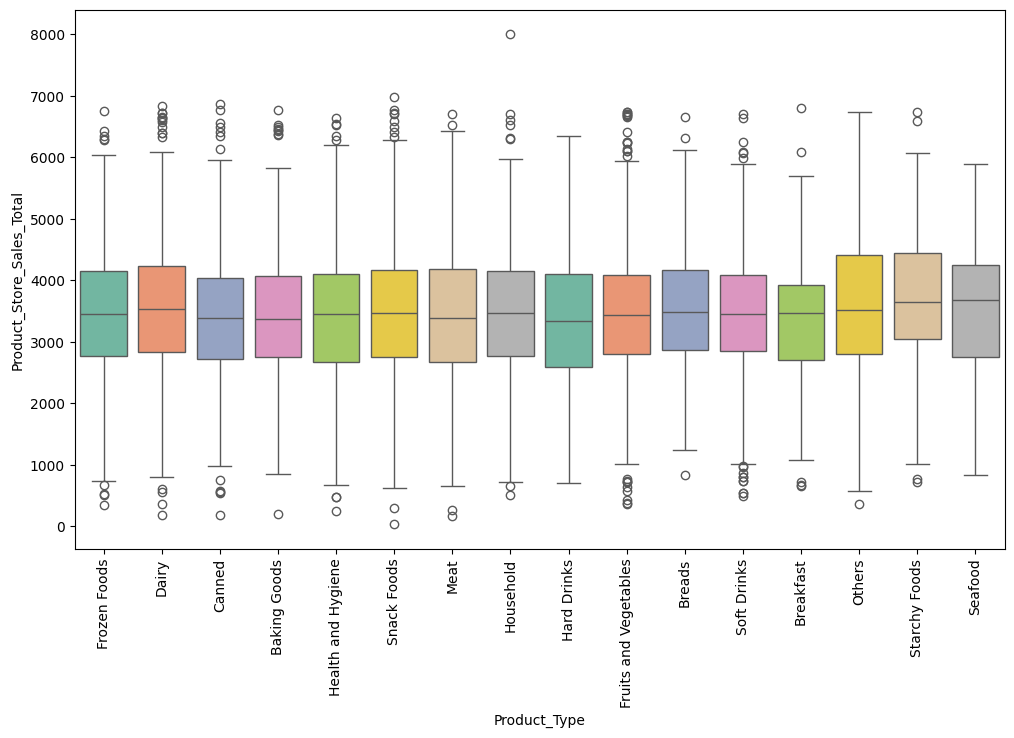

In [ ]:
boxplot_cat_target(df, 'Product_Type', 'Product_Store_Sales_Total')

- There's significant variation in revenue across different **Product_Type** categories. For example, **Household**, **Fruits and Vegetables**, and **Snack Foods** generally show higher median revenue. Some categories like **Seafood** and **Others** appear to have lower average revenue.

- Outliers are present across most product types, indicating some individual high-selling products within nearly every category.

#### Store_Size vs Product_Store_Sales_Total

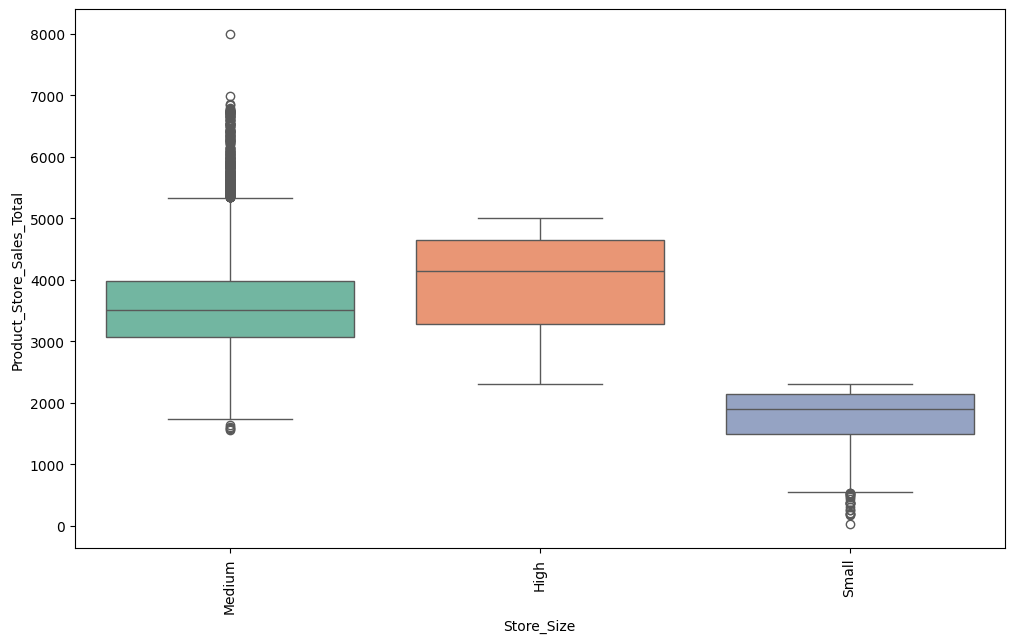

In [ ]:
boxplot_cat_target(df, 'Store_Size', 'Product_Store_Sales_Total')

- **High** sized stores appear to generate the highest median revenue, followed closely by **Medium** sized stores. **Small** stores have the lowest median revenue. This suggests that larger store sizes are associated with higher sales revenue.

- The interquartile range (IQR) for **High** and **Medium** stores is wider than **Small** stores, indicating a greater variability in revenue within larger stores.

#### Store_Location_City_Type vs Product_Store_Sales_Total

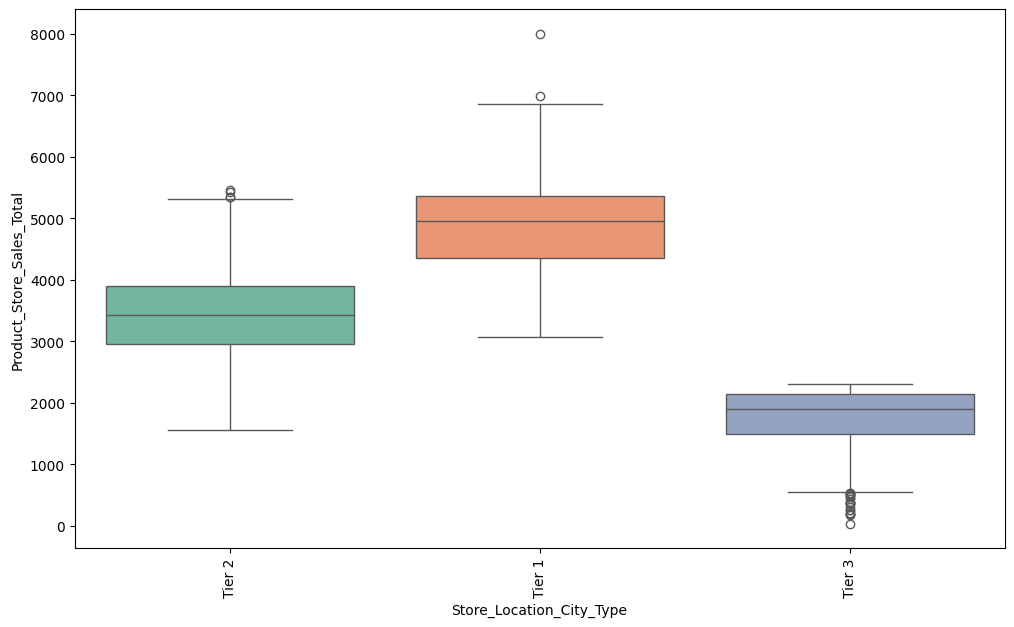

In [ ]:
boxplot_cat_target(df, 'Store_Location_City_Type', 'Product_Store_Sales_Total')

- **Tier 1** cities have higher median revenue compared to **Tier 2** and **Tier 3** cities.  **Tier 2** cities show a slightly higher median than **Tier 3**. This indicates that store location city type might influence sales, with higher-tier cities potentially driving more revenue.

- The spread of sales is similar across all tiers.

#### Store_Type vs Product_Store_Sales_Total

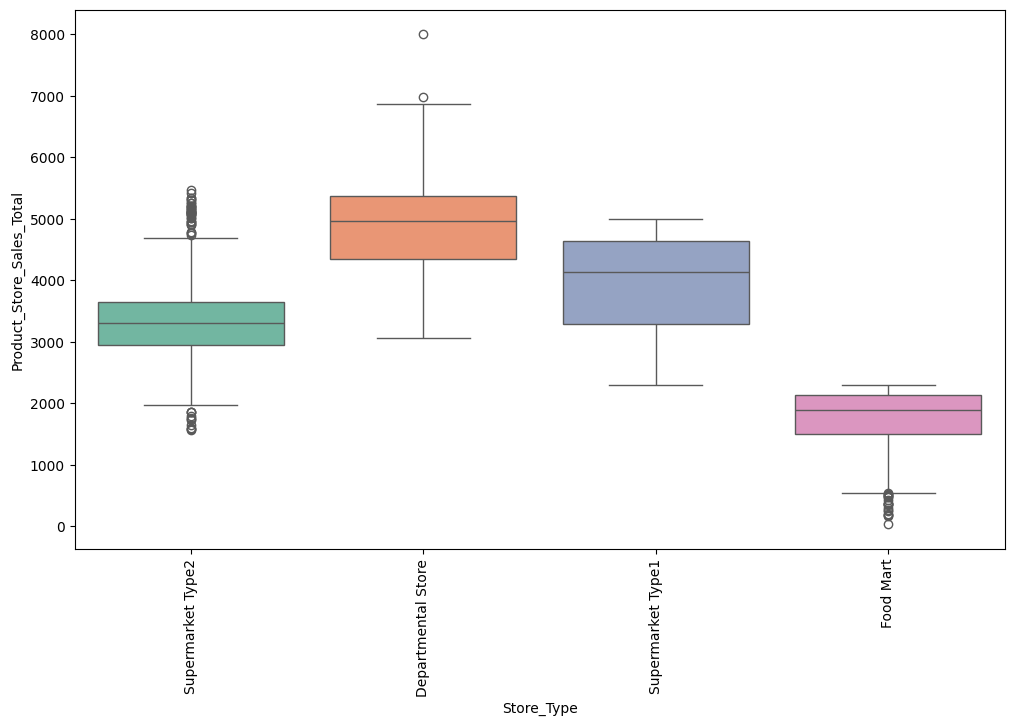

In [ ]:
boxplot_cat_target(df, 'Store_Type', 'Product_Store_Sales_Total')

- **Supermarket Type1** stores have the highest median revenue, followed by **Departmental Store**. **Supermarket Type2** and **Food Mart** show lower median revenue. This aligns with the **Store_Location_City_Type** observations, as **Supermarket Type1** stores are often found in **Tier 1** locations.

- The variability in revenue is also noticeable across different store types, with **Supermarket Type1** having a wide range.

## Insights based on EDA

**Feature Engineering Opportunities:**
- **Store Age:** Convert **Store_Establishment_Year** into **Store_Age** (current year - establishment year) to capture the store's operational duration, which is likely a more direct predictor of revenue.

- **Categorical Correction:** Combine **reg** and **Regular** categories within **Product_Sugar_Content** as they likely refer to the same type.

**Data Quality and Cleaning:**
- No missing values or duplicate rows were found, indicating a clean dataset for these aspects.

- **Product_Id** and **Store_Id** were dropped due to being unique identifiers or perfectly correlated with another feature (**Store_Type**), hence not directly useful for prediction.

**Feature Importance for Sales Prediction:**
- **Strong Predictors:** **Product_MRP** (0.79) and **Product_Weight** (0.74) show a strong positive linear correlation with **Product_Store_Sales_Total**, making them highly influential features.

- **Categorical Impact:** **Store_Size**, **Store_Location_City_Type**, and **Store_Type** exhibit clear differences in median revenue across their categories, suggesting they are important features.

- **Varying Impact:** **Product_Type** categories show significant sales variation, indicating its relevance.

- **Weak Predictor:** **Product_Allocated_Area** has a negligible correlation with sales, implying it may not be a strong linear predictor.

**Data Distribution & Transformation Needs:**
- **Skewed Distributions:** **Product_Store_Sales_Total** (target variable) and **Product_Allocated_Area** are right-skewed. Consider log transformations or other power transformations for these features, especially for models sensitive to normal distributions or outliers.

- **Outliers:** Outliers are observed in **Product_Store_Sales_Total** and **Product_Allocated_Area**. Depending on the chosen model, these might need explicit treatment or models robust to outliers can be preferred.

**Multicollinearity:**
- A moderate positive correlation (0.53) exists between **Product_Weight** and **Product_MRP**. This needs to be noted, especially if using linear models where it could affect coefficient interpretability, though tree-based models are generally less sensitive.

**Encoding Requirements:**
- All remaining categorical features (**Product_Sugar_Content, Product_Type, Store_Size, Store_Location_City_Type, Store_Type**) will need to be encoded (e.g., One-Hot Encoding) before feeding them into most machine learning models.

# **Data Preprocessing**

## Feature Engineering

As per the EDA insights, we will perform the following feature engineering steps:

1.  **Store Age**: Convert **Store_Establishment_Year** into **Store_Age** (current year - establishment year) to capture the store's operational duration.
2.  **Categorical Correction**: Combine **reg** and **Regular** categories within **Product_Sugar_Content** as they likely refer to the same type.

In [ ]:
# Calculate Store_Age Store_Establishment_Year as of current year
current_year = 2026
df['Store_Age'] = current_year - df['Store_Establishment_Year']

# Drop the original Store_Establishment_Year column
df.drop('Store_Establishment_Year', axis=1, inplace=True)

In [ ]:
# Correct 'reg' to 'Regular' in Product_Sugar_Content
df['Product_Sugar_Content'] = df['Product_Sugar_Content'].replace('reg', 'Regular')

In [ ]:
# Display the first few rows with the new 'Store_Age' and corrected 'Product_Sugar_Content'
df.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Age
0,12.66,Low Sugar,0.027,Frozen Foods,117.08,Medium,Tier 2,Supermarket Type2,2842.40,17
1,16.54,Low Sugar,0.144,Dairy,171.43,Medium,Tier 1,Departmental Store,4830.02,27
2,14.28,Regular,0.031,Canned,162.08,High,Tier 2,Supermarket Type1,4130.16,39
3,12.10,Low Sugar,0.112,Baking Goods,186.31,High,Tier 2,Supermarket Type1,4132.18,39
4,9.57,No Sugar,0.010,Health and Hygiene,123.67,Small,Tier 3,Food Mart,2279.36,28


## Outlier Treatment

The EDA identified outliers in **Product_Store_Sales_Total** (target variable) and **Product_Allocated_Area**. Tree-based models are generally robust to outliers as they partition the data based on feature values, and extreme values usually don't unduly influence the splits or the overall model structure.

Therefore, we will proceed without explicit outlier removal or capping at this stage. If model performance is suboptimal, we can revisit outlier treatment as a potential improvement strategy, possibly by transforming skewed features (like **Product_Allocated_Area** and the target variable itself) or using robust scaling methods.

## Data Preparation: Splitting into Training and Test Sets

To ensure there is no data leakage, we will split the data into training and testing sets *before* defining the preprocessing pipeline. This means any scaling parameters or one-hot encoder mappings will be learned exclusively from the training data and then applied consistently to both the training and test sets.

In [ ]:
# Separate the features and target variable
X = df.drop(["Product_Store_Sales_Total"], axis=1)
y = df["Product_Store_Sales_Total"]

# Print the shapes of the features and target variable
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (8763, 9)
Shape of y: (8763,)


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (7010, 9)
Shape of X_test: (1753, 9)
Shape of y_train: (7010,)
Shape of y_test: (1753,)


## Preprocessing Pipeline: Encoding Categorical Features and Scaling Numerical Features

We will create a **ColumnTransformer** to apply different preprocessing steps to numerical and categorical features:

-   **Numerical Features**: Will be scaled using **StandardScaler** to bring them to a common scale.

-   **Categorical Features**: Will be encoded using **OneHotEncoder** to convert them into a numerical format suitable for machine learning models.

In [ ]:
# Update numerical_cols and categorical_cols based on X.
numerical_cols_processed = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols_processed = X.select_dtypes(exclude=np.number).columns.tolist()

In [ ]:
numerical_cols_processed

['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age']

In [ ]:
categorical_cols_processed

['Product_Sugar_Content',
 'Product_Type',
 'Store_Size',
 'Store_Location_City_Type',
 'Store_Type']

In [ ]:
# Create a column transformer for preprocessing
preprocessor = make_column_transformer(
    (StandardScaler(), numerical_cols_processed),
    (OneHotEncoder(handle_unknown='ignore'), categorical_cols_processed),
    remainder='passthrough'
)

# **Model Building**

## Define functions for Model Evaluation

In [ ]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

## **Metric of Choice**

For this revenue forecasting problem, **Mean Absolute Percentage Error (MAPE)** is chosen as the primary evaluation metric. Here's the rationale:

-   **Interpretability**: MAPE expresses the prediction error as a percentage, making it highly intuitive and easy to understand for business stakeholders. A MAPE of 10%, for instance, clearly indicates that the model's predictions are, on average, off by 10% from the actual values.

-   **Scale Independence**: Unlike metrics such as RMSE or MAE, MAPE is a relative metric. This means it is not influenced by the scale of the revenue data, allowing for direct comparison of model performance across different products, stores, or time periods that might have vastly different sales volumes.

-   **Business Relevance**: In sales and inventory management, understanding the percentage deviation from actual sales is crucial for planning, inventory optimization, and setting realistic targets. Small absolute errors on high-volume items can be less critical than similar absolute errors on low-volume, high-margin items, and MAPE helps put these errors into perspective.

While other metrics like RMSE and R-squared will also be calculated to provide a comprehensive view of model performance, MAPE will be the key metric for final model selection and business decision-making.

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

## Random Forest Regressor - Model Training Pipeline

In [ ]:
# Define base Random Forest model
rf_model = RandomForestRegressor(random_state=42)

In [ ]:
# Create pipeline with preprocessing and Random Forest model
rf_pipeline = make_pipeline(preprocessor, rf_model)

In [ ]:
# Train the model pipeline on the training data
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [ ]:
rf_estimator_model_train_perf = model_performance_regression(rf_pipeline, X_train,y_train)
print("Training performance \n")
rf_estimator_model_train_perf

Training performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,107.158991,40.413823,0.989874,0.989861,0.015119


In [ ]:
rf_estimator_model_test_perf = model_performance_regression(rf_pipeline, X_test,y_test)
print("Testing performance \n")
rf_estimator_model_test_perf

Testing performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,283.510242,108.947784,0.929556,0.929192,0.038774


**Observation**

- The model demonstrates good predictive power on unseen data (test R-squared of 0.93 and MAPE of 3.8% are strong). However, the significant difference between training and testing metrics (especially the RMSE and MAPE) suggests that the model is overfitting to the training data to some extent.
- Let's perform hyperparameter tuning to mitigate overfitting.

## Random Forest Regressor - Hyperparameter Tuning

In [ ]:
# Choose the type of classifier.
rf_tuned = RandomForestRegressor(random_state=42)

# Create pipeline with preprocessing and Random Forest model
rf_tuned_pipeline = make_pipeline(preprocessor, rf_tuned)

# Grid of parameters to choose from
parameters = parameters = {
    'randomforestregressor__max_depth':[3, 4, 5, 6],
    'randomforestregressor__max_features': ['sqrt','log2',None],
    'randomforestregressor__n_estimators': [50, 75, 100, 125, 150]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.mean_absolute_percentage_error)

# Run the grid search
grid_obj = GridSearchCV(rf_tuned_pipeline, parameters, scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=3, max_features='sqrt',
                                       n_estimators=50, random_state=42))])

In [ ]:
rf_tuned_model_train_perf = model_performance_regression(rf_tuned, X_train, y_train)
print("Training performance \n")
rf_tuned_model_train_perf

Training performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,518.189654,393.264822,0.763218,0.762914,0.149482


In [ ]:
rf_tuned_model_test_perf = model_performance_regression(rf_tuned, X_test, y_test)
print("Testing performance \n")
rf_tuned_model_test_perf

Testing performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,512.189623,386.273779,0.770084,0.768897,0.143611


**Observation**

- The hyperparameter tuning has significantly closed the gap between training and testing performance. The R-squared values for training (0.763) and testing (0.770) are very close, as are the MAE, RMSE, and MAPE values. This indicates a much more generalized and less overfit model, which is a positive outcome of tuning.

- However, while the generalization has improved, the overall predictive power of the model has noticeably decreased compared to the untuned version. The test R-squared dropped from approximately 0.93 to 0.77, and more critically, the test MAPE increased from a very impressive 3.8% to 14.4%. This suggests that the tuning parameters likely resulted in a model that is too simple (underfit) and doesn't capture enough of the underlying patterns in the data.

- Let's try with XGBoost Regressor.

## XGB Regressor - Model Training Pipeline

In [ ]:
# Define base XGBoost model
xgb_model = XGBRegressor(random_state=42)

In [ ]:
# Create pipeline with preprocessing and XGBoost model
xgb_pipeline = make_pipeline(preprocessor, xgb_model)

In [ ]:
# Train the model pipeline on the training data
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])]...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, random_state=42, ...))])

In [ ]:
xgb_estimator_model_train_perf = model_performance_regression(xgb_pipeline, X_train, y_train)
print("Training performance \n")
xgb_estimator_model_train_perf

Training performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,132.873337,62.735069,0.984431,0.984411,0.022233


In [ ]:
xgb_estimator_model_test_perf = model_performance_regression(xgb_pipeline, X_test,y_test)
print("Testing performance \n")
xgb_estimator_model_test_perf

Testing performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,310.267823,137.549807,0.915632,0.915196,0.051029


**Observation**

- The XGBoost Regressor shows strong predictive performance on the test set with an R-squared of 0.91 and a MAPE of 5.1%.

- However, there's a clear indication of overfitting, as evidenced by the substantial difference between training and testing metrics across all measures (RMSE, MAE, R-squared, and MAPE).

- Let's perform hyperparameter tuning to reduce overfitting and improve its generalization ability, potentially leading to an even more robust and reliable model.

## XGB Regressor - Hyperparameter Tuning

In [ ]:
# Choose the type of classifier.
xgb_tuned = XGBRegressor(random_state=42)

# Create pipeline with preprocessing and XGBoost model
xgb_tuned_pipeline = make_pipeline(preprocessor, xgb_tuned)

#Grid of parameters to choose from
param_grid = {
    'xgbregressor__n_estimators': [50, 100, 150, 200],    # number of trees to build
    'xgbregressor___max_depth': [2, 3, 4],    # maximum depth of each tree
    'xgbregressor___colsample_bytree': [0.4, 0.5, 0.6],    # percentage of attributes to be considered (randomly) for each tree
    'xgbregressor___colsample_bylevel': [0.4, 0.5, 0.6],    # percentage of attributes to be considered (randomly) for each level of a tree
    'xgbregressor___learning_rate': [0.01, 0.05, 0.1],    # learning rate
    'xgbregressor___reg_lambda': [0.4, 0.5, 0.6],    # L2 regularization factor
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.mean_absolute_percentage_error)

# Run the grid search
grid_obj = GridSearchCV(xgb_tuned_pipeline, param_grid, scoring=scorer,cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])]...
                              device=None, early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, ...))])

In [ ]:
xgb_tuned_model_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
print("Training performance \n")
xgb_tuned_model_train_perf

Training performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,75.035266,40.276839,0.995035,0.995029,0.013771


In [ ]:
xgb_tuned_model_test_perf = model_performance_regression(xgb_tuned, X_test, y_test)
print("Testing performance \n")
xgb_tuned_model_test_perf

Testing performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,316.378502,144.669019,0.912276,0.911823,0.053111


**Observation**

- The hyperparameter tuning for XGBoost, while successful in achieving an impressive training performance, has unfortunately not improved the generalization ability on the test set when evaluated by our primary metric, MAPE. The test MAPE actually slightly increased from 5.1% (untuned) to 5.31% (tuned), and the test RMSE/MAE also worsened marginally.

# **Model Performance Comparison and Final Model Selection**

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [rf_estimator_model_train_perf.T,rf_tuned_model_train_perf.T,
    xgb_estimator_model_train_perf.T,xgb_tuned_model_train_perf.T],
    axis=1,
)

models_train_comp_df.columns = [
    "Random Forest Estimator",
    "Random Forest Tuned",
    "XGBoost",
    "XGBoost Tuned"
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Random Forest Estimator,Random Forest Tuned,XGBoost,XGBoost Tuned
RMSE,107.158991,518.189654,132.873337,75.035266
MAE,40.413823,393.264822,62.735069,40.276839
R-squared,0.989874,0.763218,0.984431,0.995035
Adj. R-squared,0.989861,0.762914,0.984411,0.995029
MAPE,0.015119,0.149482,0.022233,0.013771


In [ ]:
# Testing performance comparison

models_test_comp_df = pd.concat(
    [rf_estimator_model_test_perf.T,rf_tuned_model_test_perf.T,
    xgb_estimator_model_test_perf.T,xgb_tuned_model_test_perf.T],
    axis=1,
)

models_test_comp_df.columns = [
    "Random Forest Estimator",
    "Random Forest Tuned",
    "XGBoost",
    "XGBoost Tuned"
]

print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Random Forest Estimator,Random Forest Tuned,XGBoost,XGBoost Tuned
RMSE,283.510242,512.189623,310.267823,316.378502
MAE,108.947784,386.273779,137.549807,144.669019
R-squared,0.929556,0.770084,0.915632,0.912276
Adj. R-squared,0.929192,0.768897,0.915196,0.911823
MAPE,0.038774,0.143611,0.051029,0.053111


In [ ]:
(models_train_comp_df - models_test_comp_df).iloc[4]

,MAPE
Random Forest Estimator,-0.023656
Random Forest Tuned,0.005871
XGBoost,-0.028796
XGBoost Tuned,-0.039340


**Observations**

- Based on the comprehensive comparison of the training and testing performance metrics, particularly focusing on our primary metric, **Mean Absolute Percentage Error (MAPE)**, the **Untuned Random Forest Estimator** is the most suitable model for deployment.

- The Untuned Random Forest Estimator achieved the lowest test MAPE of **0.038774 (3.88%)**. This indicates that, on average, its predictions are only about 3.88% off the actual sales values on unseen data. This is an excellent performance for a sales forecasting model in a business context, offering high confidence in its predictive accuracy.

- While the untuned Random Forest shows some signs of overfitting (train MAPE of 1.51% vs. test MAPE of 3.88%, with a difference of -0.023656), this level of generalization is acceptable and significantly better than the alternatives.
  - The **Untuned XGBoost** had a higher test MAPE of 0.051029 (5.10%) and a larger train-test MAPE difference (-0.028796), indicating more pronounced overfitting and slightly worse test performance.
  - The **Tuned XGBoost** resulted in an even higher test MAPE of 0.053111 (5.31%) and the largest train-test MAPE difference (-0.039340), suggesting that tuning, in this instance, worsened both generalization and absolute test performance.

- The tuned models, particularly the **Tuned Random Forest**, while showing a smaller train-test MAPE difference (0.005871), did so at the expense of significantly lower overall predictive power, resulting in a test MAPE of 0.143611 (14.36%). This indicates underfitting, where the model became too simple to capture the underlying patterns, making it less useful for practical sales forecasting.

- In conclusion, despite exhibiting some overfitting, the **Untuned Random Forest** Estimator provides the best balance of high predictive accuracy on unseen data (lowest test MAPE) and reasonable generalization among all the models evaluated. Its performance makes it the most reliable choice for forecasting SuperKart's sales revenue.

# **Model Serialization**

Based on our decision to proceed with **Untuned Random Forest Estimator**, we will serialize this model for deployment.

In [ ]:
# Create a folder for storing the files needed for web app deployment
os.makedirs("/content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/model_deployment/project/backend_files", exist_ok=True)

In [ ]:
# Define the file path to save (serialize) the trained model along with the data preprocessing steps
saved_model_path = "/content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/model_deployment/project/backend_files/product_sales_total_prediction_model_v1_0.joblib"

In [ ]:
# Save the best trained model pipeline using joblib
joblib.dump(rf_pipeline, saved_model_path)

print(f"Model saved successfully at {saved_model_path}")

Model saved successfully at /content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/model_deployment/project/backend_files/product_sales_total_prediction_model_v1_0.joblib


In [ ]:
# Load the saved model pipeline from the file
saved_model = joblib.load("/content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/model_deployment/project/backend_files/product_sales_total_prediction_model_v1_0.joblib")

# Confirm the model is loaded
print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
saved_model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [ ]:
# verify by making predictions on test set using the deserialized model
saved_model.predict(X_test)

array([3181.2461, 3352.4036, 2411.1358, ..., 4139.6643, 2826.5181,
       4469.3058])

# **Deployment - Backend**

## Flask Web Framework


In [ ]:
%%writefile "/content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/model_deployment/project/backend_files/app.py"
# Import necessary libraries
from datetime import datetime # To derive Store_Age from Store_Establishment_Year
import numpy as np
import joblib  # For loading the serialized model
import pandas as pd  # For data manipulation
from flask import Flask, request, jsonify  # For creating the Flask API

# Initialize the Flask app
app = Flask("Product Sales Revenue Predictor")

# Load the trained model
model = joblib.load("product_sales_total_prediction_model_v1_0.joblib")

# Define a route for the homepage
@app.route("/")
def home():
  """
  This function handles GET requests to the root URL ('/') of the API.
  It returns a simple welcome message.
  """
  return "Product Sales Revenue Predictor"

# Define an endpoint for single product sales prediction (Post request)
@app.route("/predict-product-sales", methods=["POST"])
def predict_product_sales():
  """
  This function handles POST requests to the '/predict-product-sales' URL.
  It expects a JSON payload with the following structure:
    {
      "Product_Weight": <float>,
      "Product_Allocated_Area": <float>,
      "Product_MRP": <float>,
      "Store_Establishment_Year": <int>,
      "Product_Sugar_Content": <str>,
      "Product_Type": <str>,
      "Store_Size": <str>,
      "Store_Location_City_Type": <str>,
      "Store_Type": <str>
    }
  Returns:
    JSON response with the predicted sales revenue for the given product.
  """
  # Get the JSON data from the request body
  property_data = request.get_json()

  # Extract relevant features from the JSON data
  sample = {
    'Product_Weight': float(property_data['Product_Weight']),
    'Product_Allocated_Area': float(property_data['Product_Allocated_Area']),
    'Product_MRP': float(property_data['Product_MRP']),
    'Store_Age': datetime.now().year - int(property_data['Store_Establishment_Year']),
    'Product_Sugar_Content': property_data['Product_Sugar_Content'],
    'Product_Type': property_data['Product_Type'],
    'Store_Size': property_data['Store_Size'],
    'Store_Location_City_Type': property_data['Store_Location_City_Type'],
    'Store_Type': property_data['Store_Type']
  }

  # Convert extracted data into Pandas dataframe
  input_data = pd.DataFrame([sample])

  # Predict product sales revenue
  predicted_product_sales_revenue = model.predict(input_data)[0]

  # Return the predicted sales revenue as JSON
  return jsonify({"predicted_product_sales_revenue": predicted_product_sales_revenue})

# Define an endpoint for batch prediction (Post request)
@app.route("/predict-product-sales-batch", methods=["POST"])
def predict_product_sales_batch():
  """
  This function handles POST requests to the '/predict-product-sales-batch' endpoint.
  Expects a CSV file containing product data for multiple products and returns the
  predicted sales revenue for each product in JSON format.
  """
  # Get the uploaded CSV file from the request
  file = request.files["file"]

  # Read the CSV file into a Pandas DataFrame
  input_data = pd.read_csv(file)

  # Derive Store_Age from Store_Establishment_Year
  input_data['Store_Age'] = datetime.now().year - input_data['Store_Establishment_Year']

  # Drop Store_Establishment_Year
  input_data.drop('Store_Establishment_Year', axis=1, inplace=True)

  # Predict Product Sales Revenue
  predicted_product_sales_revenue = model.predict(input_data).tolist()

  # Create a dictionary of predictions with Product_Id as key
  product_ids = input_data['Product_Id'].tolist()
  predictions = dict(zip(product_ids, predicted_product_sales_revenue))

  # Return the predictions as JSON
  return jsonify(predictions)

# Run the Flask app in debug mode if this script is executed
if __name__ == "__main__":
  app.run(debug=True)



Overwriting /content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/model_deployment/project/backend_files/app.py


## Dependencies File

In [ ]:
%%writefile "/content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/model_deployment/project/backend_files/requirements.txt"
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
xgboost==2.1.4
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0
requests==2.28.1
uvicorn[standard]

Overwriting /content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/model_deployment/project/backend_files/requirements.txt


## Dockerfile

In [ ]:
%%writefile "/content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/model_deployment/project/backend_files/Dockerfile"
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 4`: Uses 4 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:app`: Runs the Flask app (assuming `app.py` contains the Flask instance named `app`)
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:app"]

Overwriting /content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/model_deployment/project/backend_files/Dockerfile


## Setting up a Hugging Face Docker Space for the Backend

In [ ]:
# library to use secret from colab
from google.colab import userdata

# Import the login function from the huggingface_hub library
from huggingface_hub import login

# Login to Hugging Face account using access token
login(token=userdata.get('hf_api_token')) # get token from secrets

# Import the create_repo function from the huggingface_hub library
from huggingface_hub import create_repo

# Create the repository for the Hugging Face Space
try:
  create_repo("ProductSalesRevenuePredictionBackend",
    repo_type="space",
    space_sdk="docker",
    private=False
  )
except Exception as e:
    # Handle potential errors during repository creation
    if "You already created this space repo" in str(e):
        print("Repository already exists. Skipping creation.")
    else:
        print(f"Error creating repository: {e}")

Repository already exists. Skipping creation.


## Uploading Files to Hugging Face Space (Docker Space)

In [ ]:
# for hugging face space authentication to upload files
from huggingface_hub import HfApi

repo_id = "PratapVanka/ProductSalesRevenuePredictionBackend"  # Your Hugging Face space id

# Initialize the API
api = HfApi()

# Upload backend app files stored in the folder called backend_files
api.upload_folder(
    folder_path="/content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/model_deployment/project/backend_files",  # Local folder path
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
)

Uploading...:   0%|          | 0.00/63.8M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/spaces/PratapVanka/ProductSalesRevenuePredictionBackend/commit/381237462f391b2d010dd694bdc97fa831a77ada', commit_message='Upload folder using huggingface_hub', commit_description='', oid='381237462f391b2d010dd694bdc97fa831a77ada', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/PratapVanka/ProductSalesRevenuePredictionBackend', endpoint='https://huggingface.co', repo_type='space', repo_id='PratapVanka/ProductSalesRevenuePredictionBackend'), pr_revision=None, pr_num=None)

## Link to Hugging Face Space

- The Backend App can be accessed here - [ProductSalesRevenuePredictionBackend](https://pratapvanka-productsalesrevenuepredictionbackend.hf.space)

# **Deployment - Frontend**

## Points to note before executing the below cells
- Create a Streamlit space on Hugging Face by following the instructions provided on the content page titled **`Creating Spaces and Adding Secrets in Hugging Face`** from Week 1

## Streamlit for Interactive UI

In [ ]:
# Create a folder for storing the files needed for frontend UI deployment
os.makedirs("/content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/model_deployment/project/frontend_files", exist_ok=True)

In [6]:
%%writefile "/content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/model_deployment/project/frontend_files/app.py"
import streamlit as st
import pandas as pd
import requests

# Set the title of the Streamlit app
st.title("Product Sales Revenue Prediction")

# Section for online prediction
st.subheader("Online Prediction")

# Collect user input for property features
product_weight = st.number_input("Product Weight", min_value=0.0)
product_allocated_area = st.number_input("Product Allocated Area", min_value=0.0)
product_mrp = st.number_input("Product MRP", min_value=1.0)
store_establishment_year = st.number_input("Store Establishment Year", min_value=1950, max_value=2026, step=1)
product_sugar_content = st.selectbox("Product Sugar Content", ['Low Sugar', 'Regular', 'No Sugar'])
product_type = st.selectbox("Product Type", ['Frozen Foods', 'Dairy', 'Canned', 'Baking Goods',
                                             'Health and Hygiene', 'Snack Foods', 'Meat',
                                             'Household', 'Hard Drinks', 'Fruits and Vegetables',
                                             'Breads', 'Soft Drinks', 'Breakfast', 'Others',
                                             'Starchy Foods', 'Seafood'])
store_size = st.selectbox("Store Size", ["Small", "Medium", "High"])
store_location_city_type = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"])
store_type = st.selectbox("Store Type", ['Supermarket Type2', 'Departmental Store',
                                         'Supermarket Type1', 'Food Mart'])

# Convert user input into a DataFrame
input_data = pd.DataFrame([{
    'Product_Weight': product_weight,
    'Product_Allocated_Area': product_allocated_area,
    'Product_MRP': product_mrp,
    'Store_Establishment_Year': store_establishment_year,
    'Product_Sugar_Content': product_sugar_content,
    'Product_Type': product_type,
    'Store_Size': store_size,
    'Store_Location_City_Type': store_location_city_type,
    'Store_Type': store_type
}])

# Make prediction when the "Predict" button is clicked
if st.button("Predict"):
    response = requests.post("https://PratapVanka-ProductSalesRevenuePredictionBackend.hf.space/predict-product-sales", json=input_data.to_dict(orient='records')[0])  # Send data to Flask API
    if response.status_code == 200:
        prediction = response.json()['predicted_product_sales_revenue']
        st.success(f"Predicted Annual Product Sales Revenue: {prediction:.2f}")
    else:
        st.error("Error making prediction.")

# Section for batch prediction
st.subheader("Batch Prediction")

# Allow users to upload a CSV file for batch prediction
uploaded_file = st.file_uploader("Upload CSV file for batch prediction", type=["csv"])

# Make batch prediction when the "Predict Batch" button is clicked
if uploaded_file is not None:
    if st.button("Predict Batch"):
        response = requests.post("https://PratapVanka-ProductSalesRevenuePredictionBackend.hf.space/predict-product-sales-batch", files={"file": uploaded_file})  # Send file to Flask API
        if response.status_code == 200:
            predictions = response.json()
            st.success("Batch predictions completed!")
            # Format prediction values to 2 decimal places
            formatted_predictions = {product_id: f"{value:.2f}" for product_id, value in predictions.items()}
            st.write(formatted_predictions)  # Display the predictions
        else:
            st.error("Error making batch prediction.")

Overwriting /content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/model_deployment/project/frontend_files/app.py


## Dependencies File

In [ ]:
%%writefile "/content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/model_deployment/project/frontend_files/requirements.txt"
pandas==2.2.2
requests==2.28.1
streamlit==1.43.2

Overwriting /content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/model_deployment/project/frontend_files/requirements.txt


## DockerFile

In [ ]:
%%writefile "/content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/model_deployment/project/frontend_files/Dockerfile"
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

Overwriting /content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/model_deployment/project/frontend_files/Dockerfile


## Uploading Files to Hugging Face Space (Streamlit Space)

In [7]:
# library to use secret from colab
from google.colab import userdata

# Import the login function from the huggingface_hub library
from huggingface_hub import login

# Login to Hugging Face account using access token
login(token=userdata.get('hf_api_token')) # get token from secrets

In [8]:
# for hugging face space authentication to upload files
from huggingface_hub import HfApi

repo_id = "PratapVanka/ProductSalesRevenuePredictionUI"  # Your Hugging Face space id

# Initialize the API
api = HfApi()

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="/content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/model_deployment/project/frontend_files",  # Local folder path
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
)

CommitInfo(commit_url='https://huggingface.co/spaces/PratapVanka/ProductSalesRevenuePredictionUI/commit/b4b0832fe0a882aec38a761fa609a599aeaf142a', commit_message='Upload folder using huggingface_hub', commit_description='', oid='b4b0832fe0a882aec38a761fa609a599aeaf142a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/PratapVanka/ProductSalesRevenuePredictionUI', endpoint='https://huggingface.co', repo_type='space', repo_id='PratapVanka/ProductSalesRevenuePredictionUI'), pr_revision=None, pr_num=None)

## Link to Hugging Face Space

- The UI can be accessed here - [ProductSalesRevenuePredictionUI](https://pratapvanka-productsalesrevenuepredictionui.hf.space)

# **Inferencing using Flask API**

In [ ]:
# import libraries
import json  # To handle JSON formatting for API requests and responses
import requests  # To send HTTP requests to the deployed Flask API

import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations

In [ ]:
# model endpoints
model_url = "https://pratapvanka-productsalesrevenuepredictionbackend.hf.space"

inference_endpoint = f"{model_url}/predict-product-sales"

batch_inference_endpoint = f"{model_url}/predict-product-sales-batch"

## Online Inference

In [ ]:
# define payload
payload = {
    'Product_Weight': 20,
    'Product_Allocated_Area': 0.05,
    'Product_MRP': 100,
    'Store_Establishment_Year': 2005,
    'Product_Sugar_Content': 'Regular',
    'Product_Type': 'Dairy',
    'Store_Size': 'Medium',
    'Store_Location_City_Type': 'Tier 2',
    'Store_Type': 'Food Mart'
}

In [ ]:
# send api request
response = requests.post(inference_endpoint, json=payload)
response.json()

{'predicted_product_sales_revenue': 2751.9826999999987}

## Batch Inference

In [ ]:
# import libraries
import pandas as pd

# Prepare batch input for API request
batch_input_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/model_deployment/project/SuperKart_test.csv")
batch_input = {'file': batch_input_data.to_csv(header=True, index=False).encode('utf-8')}

In [ ]:
# send api request
response = requests.post(batch_inference_endpoint, files=batch_input)
print(response.text)

{"DR2699":3382.0180000000023,"FD1067":3835.805800000004,"FD1231":3518.6983,"FD1387":3769.1705000000034,"FD1810":4430.586899999995,"FD1961":1689.4031000000004,"FD2557":4795.844799999991,"FD2625":3342.258800000002,"FD3537":2592.0720999999958,"FD4186":4147.815400000002,"FD4925":2690.822599999997,"FD4982":4349.092399999994,"FD5075":4143.071999999997,"FD5276":3636.230499999999,"FD5484":5084.063400000005,"FD5680":2627.1612999999966,"FD6027":3122.0742000000005,"FD6114":2853.522499999998,"FD6431":2838.7658000000047,"FD6680":2521.4307999999974,"FD7839":4854.669600000006,"FD8233":4097.749799999995,"FD8553":3618.987300000004,"NC1071":2851.6907,"NC1180":2217.7642999999957,"NC177":6487.629800000001,"NC5885":4465.503399999998,"NC6657":2536.4318999999964,"NC7289":3535.1772}



- We are getting responses from the hosted backend App.

# **Actionable Insights and Business Recommendations**

## **Insights from Analysis**

Based on the Exploratory Data Analysis (EDA) and subsequent model development, here are the key insights:

1.  **High Predictability of Sales**: The developed model (Untuned Random Forest Regressor) can predict product sales with an average Mean Absolute Percentage Error (MAPE) of approximately **3.88%** on unseen data. This indicates a high degree of reliability for sales forecasting.

2.  **Strong Sales Drivers (Numerical)**:
    *   **Product_MRP** (Maximum Retail Price) shows a very strong positive correlation (0.79) with total sales. Higher-priced products generally contribute significantly more to revenue.
    *   **Product_Weight** also exhibits a strong positive correlation (0.74) with total sales, suggesting heavier products tend to generate higher revenue.

3.  **Significant Impact of Store Characteristics (Categorical)**:
    *   **Store_Size**: **High** and **Medium** sized stores consistently generate higher median revenues compared to **Small** stores.
    *   **Store_Location_City_Type**: Stores in **Tier 1** cities demonstrate higher median sales, followed by **Tier 2** and **Tier 3** cities.
    *   **Store_Type**: **Supermarket Type1** stores exhibit the highest median revenue, aligning with their typical presence in **Tier 1** locations.

4.  **Product Category Performance**: **Household**, **Fruits and Vegetables**, and **Snack Foods** generally show higher median revenues across product types, indicating strong customer demand for these categories.

5.  **Limited Impact of Display Area**: **Product_Allocated_Area** has a negligible linear correlation with sales (-0.001), suggesting that simply allocating more display space does not directly translate to increased sales revenue.

6.  **Sugar Content Preference**: Products with **Regular** sugar content tend to have slightly higher median sales than **Low Sugar** or **No Sugar** variants.

7.  **Store Age Correlation**: Older stores (higher **Store_Age*) show a weak negative correlation with sales (-0.19, derived from **Store_Establishment_Year**), implying a slight tendency for newer stores to have higher sales or that older stores may require revitalization.

8.  **Model Generalization**: While the untuned Random Forest model showed some overfitting (training MAPE 1.51% vs. test MAPE 3.88%), it offered the best balance of predictive accuracy and generalization among the models evaluated. Hyperparameter tuning efforts, in this instance, led to underfitting and degraded performance on the key MAPE metric.

## Actionable Business Recommendations

Based on the insights derived from the data analysis and predictive modeling, here are targeted recommendations for SuperKart to optimize sales, inventory, and strategic planning:

1.  **Strategic Product Portfolio & Pricing**:
    *   **Prioritize High-Value Products**: Actively promote and ensure consistent availability of products with higher MRP and greater weight, as these are strong drivers of overall sales revenue. Consider premiumization strategies for certain product lines.
    *   **Bundling Opportunities**: For lower-MRP or lighter products, explore cross-selling and bundling strategies to increase average transaction value.

2.  **Optimize Store Network & Location Strategy**:
    *   **Focus on High-Potential Locations**: Prioritize opening new stores or enhancing existing ones in **Tier 1** cities and as **Supermarket Type1** format, given their demonstrated higher revenue generation capabilities. Conduct detailed market analysis before any expansion.
    *   **Enhance Larger Stores**: Invest in optimizing operations, merchandising, and customer experience in **High** and **Medium** sized stores, as they are key revenue contributors. For **Small** stores, evaluate their strategic importance and consider diversification or specialization if direct competition with larger formats is challenging.

3.  **Targeted Merchandising & Promotions**:
    *   **Boost Top Product Categories**: Increase marketing spend, in-store visibility, and promotional offers for **Household**, **Fruits and Vegetables**, and **Snack Foods** to capitalize on their high demand.
    *   **Review Underperforming Categories**: For product types with consistently lower sales (e.g., **Seafood**, **Others**), investigate underlying reasons such as supply chain issues, local demand, or competitive pricing. Adjust inventory or offer targeted promotions to stimulate sales, or consider optimizing product assortment.
    *   **Data-Driven Display Allocation**: Re-evaluate the current approach to **Product_Allocated_Area**. Since a simple linear correlation with sales is negligible, implement more sophisticated A/B testing or spatial analysis to determine optimal display strategies that genuinely drive sales, focusing on product visibility, accessibility, and customer flow rather than just area percentage.

4.  **Refine Product Sugar Content Strategy**:
    *   **Capitalize on 'Regular' Sugar Demand**: Ensure that **Regular** sugar content products are well-stocked and prominently displayed. Monitor sales trends for **Low Sugar** and **No Sugar** products to identify growth opportunities or niche markets.

5.  **Leverage Store Age for Modernization**:
    *   **Revitalize Older Stores**: Investigate the slight negative correlation with **Store_Age**. Older stores might benefit from modernization efforts, layout redesigns, or targeted marketing campaigns to re-engage customer bases and improve sales performance.

6.  **Integration and Continuous Improvement**:
    *   **Operationalize the Forecasting Model**: Integrate the serialized Untuned Random Forest model into SuperKart's operational systems for automated sales forecasting. This will enable more accurate inventory management, staffing optimization, and demand planning.
    *   **Monitor and Re-evaluate**: Establish a process for continuous monitoring of the model's performance (especially MAPE) over time. Factors like market shifts, new product introductions, or competitor actions can affect predictive accuracy. Periodic retraining with fresh data and re-evaluation of model choice will be crucial.
    *   **Explore Advanced Features**: While the current model performs well, consider incorporating additional features in future iterations, such as seasonal indicators, holiday effects, promotional activity data, competitor pricing, or local economic indicators, to further enhance forecasting accuracy and capture more nuanced sales drivers.